<a href="https://colab.research.google.com/github/componavt/dictorpus-space/blob/main/src/notebooks/ludic_verb_stems_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📊 Ludic Verb Stem Distribution Visualization (Dictionary vs Corpus)

This notebook cell clones the `dictorpus-space` repo, loads **TWO CSV files** (dictionary lemmas + corpus tokens), and visualizes the distribution of Ludic verb stems with **comparative grouped bars**.

- 🔍 **Dual data sources**: Reads lemma-level statistics from `ludic_verb_stems_distribution_dictionary.csv` (VepKar dictionary) AND token-level statistics from `ludic_verb_stems_tokens_distribution_corpus.csv` (corpus).
- 📈 **Grouped horizontal bars**: For each ending category, displays **two bars** — dictionary (solid outline, above) and corpus (dotted outline, below) — enabling direct visual comparison.
- ↔️ **Bidirectional X-axes**: One-stem bars grow rightward from 0 (top X-axis); two-stem bars grow leftward from the right edge (bottom X-axis, reversed scale).
- ⬜ **Centered "прочие" category**: The "other" ending is positioned at 50% of the X-axis (centered), as it belongs to neither one-stem nor two-stem groups.
- 🎨 **Print-optimized B/W design**: Uses grayscale + hatching patterns (`///` for two-stem dictionary, `...` for two-stem corpus) for black-and-white publication. Small values (<1%) are amplified 3× for visibility while preserving original percentage labels.
- 📋 **Dual legends**: Two separate legends at bottom (left: one-stem verbs; right: two-stem verbs) explaining the visual encoding for dictionary vs corpus.
- 🔤 **Russian labels**: All axis labels, tick labels, title, and legend text are in Russian for the target audience.
- 💾 **Multi-format export**: Saves the figure in PNG (300 DPI) and TIFF (300 DPI, LZW compression) formats for publication.
- 📏 **Custom axis positioning**: X-axis labels are horizontally shifted (left: 0.34, right: 0.85) for better visual balance.

✅ Repository ready

Saved: ludic_verb_stems_dict_corpus_bw.png, ludic_verb_stems_dict_corpus_bw.tif


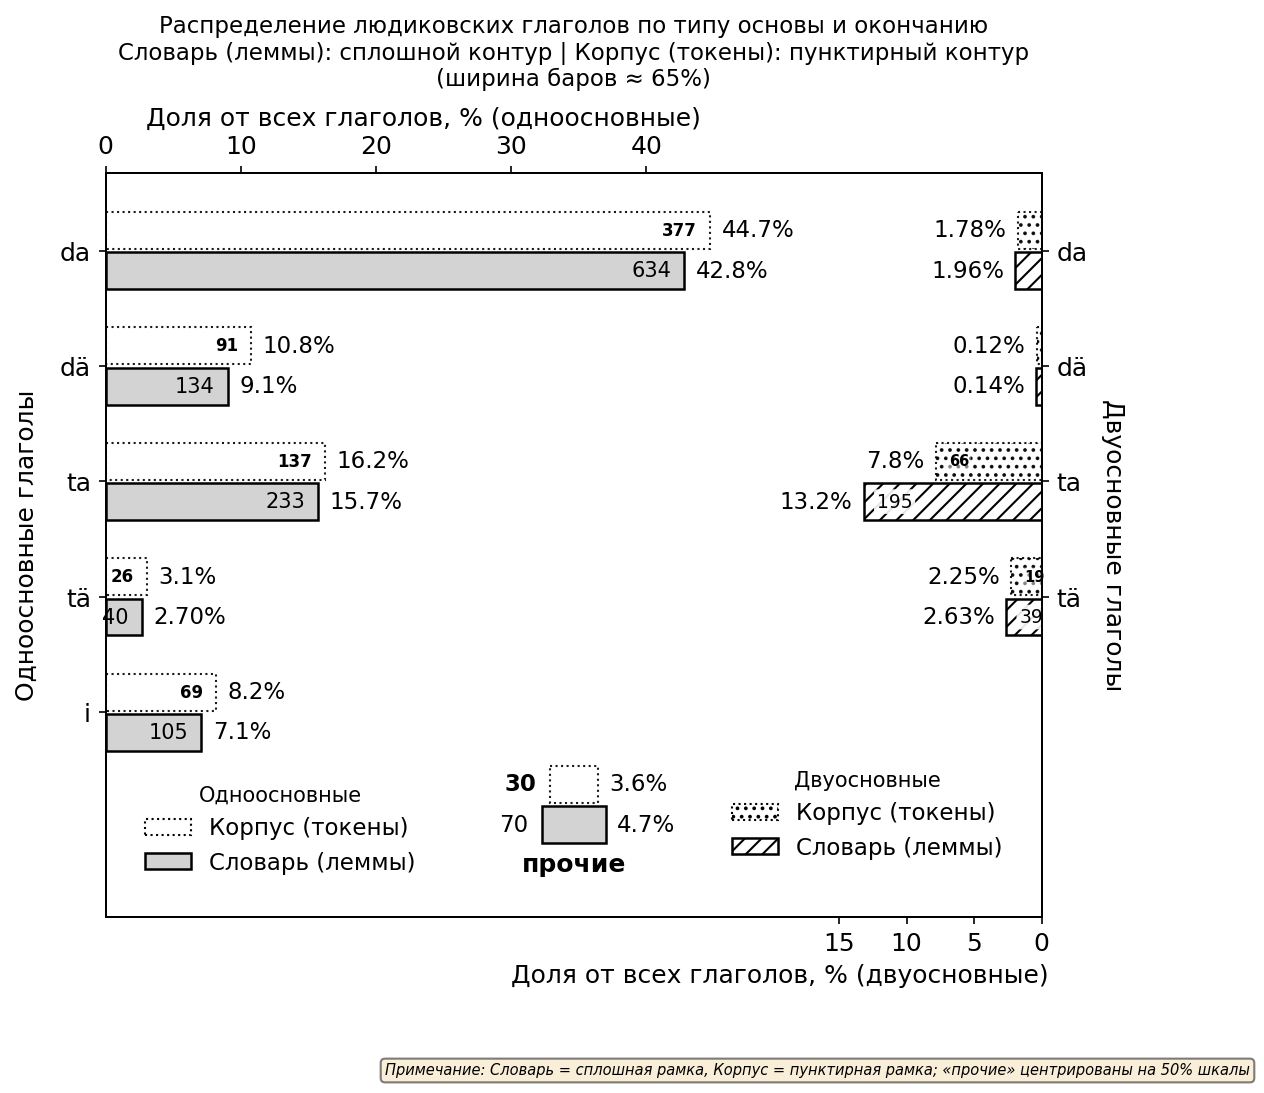

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

# === Display parameters ===
ANNOT_BG_ALPHA = 0.9      # background transparency for numbers in hatched bars
X_WIDTH_PERCENT = 65      # percentage of total X width occupied by bars
BAR_GROUP_GAP = 0.35      # vertical gap between dictionary and corpus bars within a group
BAR_HEIGHT = 0.32         # height of each individual bar (reduced for grouping)

# === Legend position parameters (adjust manually) ===
LEGEND_LOC = "upper right"
LEGEND_X_LEFT = 0.02      # X-coordinate for LEFT legend (0.0 = left edge)
LEGEND_X_RIGHT = 0.98     # X-coordinate for RIGHT legend (1.0 = right edge)
LEGEND_Y_BOTTOM = 0.05   # Y-coordinate for BOTH legends (negative = below plot)
LEGEND_NCOL = 1

# === Step 1: Clone repository ===
github_user = "componavt"
repo = "dictorpus-space"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}
print("✅ Repository ready\n")

# === Step 2: Load CSV files ===
# Dictionary data (lemmas)
csv_dict = "src/notebooks/ludic_verb_stems_distribution_dictionary.csv"
df_dict = pd.read_csv(csv_dict)
df_dict = df_dict[df_dict["type"] != "total"].copy()

# Corpus data (tokens)
csv_corpus = "src/notebooks/ludic_verb_stems_tokens_distribution_corpus.csv"
df_corpus = pd.read_csv(csv_corpus)
df_corpus = df_corpus[df_corpus["type"] != "total"].copy()

def get_val(df, ending, type_):
    """Get count and percent for a given ending and type from dataframe."""
    r = df[(df["ending"] == ending) & (df["type"] == type_)]
    return (int(r.iloc[0]["count"]), float(r.iloc[0]["percent"])) if not r.empty else (0, 0.0)

# === Left side: one-stem (excluding "прочие") ===
left_labels = ["da", "dä", "ta", "tä", "i"]
left_endings = ["da", "dä", "ta", "tä", "i"]
left_type = "one_stem"

# Dictionary data (left side, one-stem)
left_dict_cnts, left_dict_pcts = [], []
for ending in left_endings:
    c, p = get_val(df_dict, ending, left_type)
    left_dict_cnts.append(c)
    left_dict_pcts.append(p)
left_dict_cnts = np.array(left_dict_cnts)
left_dict_pcts = np.array(left_dict_pcts)

# Corpus data (left side, one-stem)
left_corpus_cnts, left_corpus_pcts = [], []
for ending in left_endings:
    c, p = get_val(df_corpus, ending, left_type)
    left_corpus_cnts.append(c)
    left_corpus_pcts.append(p)
left_corpus_cnts = np.array(left_corpus_cnts)
left_corpus_pcts = np.array(left_corpus_pcts)

# === Right side: two-stem ===
right_labels = ["da", "dä", "ta", "tä"]
right_endings = ["da", "dä", "ta", "tä"]
right_type = "two_stem"

# Dictionary data (right side, two-stem)
right_dict_cnts, right_dict_pcts = [], []
for ending in right_endings:
    c, p = get_val(df_dict, ending, right_type)
    right_dict_cnts.append(c)
    right_dict_pcts.append(p)
right_dict_cnts = np.array(right_dict_cnts)
right_dict_pcts = np.array(right_dict_pcts)

# Corpus data (right side, two-stem)
right_corpus_cnts, right_corpus_pcts = [], []
for ending in right_endings:
    c, p = get_val(df_corpus, ending, right_type)
    right_corpus_cnts.append(c)
    right_corpus_pcts.append(p)
right_corpus_cnts = np.array(right_corpus_cnts)
right_corpus_pcts = np.array(right_corpus_pcts)

# === Center: "прочие" (other) - positioned at 50% of X axis ===
other_dict_cnt, other_dict_pct = get_val(df_dict, "other", "other")
other_corpus_cnt, other_corpus_pct = get_val(df_corpus, "other", "other")

# === Y positions for grouped bars ===
y_base_left = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_base_right = np.array([0.0, 1.0, 2.0, 3.0])
y_base_other = 4.8

# Grouped positions: dictionary bar ABOVE, corpus bar BELOW
y_dict_left = y_base_left + BAR_GROUP_GAP / 2
y_corpus_left = y_base_left - BAR_GROUP_GAP / 2
y_dict_right = y_base_right + BAR_GROUP_GAP / 2
y_corpus_right = y_base_right - BAR_GROUP_GAP / 2
y_dict_other = y_base_other + BAR_GROUP_GAP / 2
y_corpus_other = y_base_other - BAR_GROUP_GAP / 2


def draw_chart():
    lv_dict = left_dict_pcts
    rv_dict = right_dict_pcts
    lv_corpus = left_corpus_pcts
    rv_corpus = right_corpus_pcts

    # Calculate axis limits
    raw_max = max(lv_dict.max(), rv_dict.max(), other_dict_pct)
    base_max = max(45.0, raw_max * 1.05)
    scale = X_WIDTH_PERCENT / 100.0
    x_max = base_max / scale
    x_center = x_max / 2

    fig, ax = plt.subplots(figsize=(11, 7))

    # ═══════════════════════════════════════════════════════════════════
    # DICTIONARY DATA (solid bars) - LEFT SIDE (one-stem)
    # ═══════════════════════════════════════════════════════════════════
    # Apply 3x multiplier for small values (<1%)
    lv_dict_visible = np.array([pct * 3 if pct < 1 else pct for pct in lv_dict])

    ax.barh(
        y_dict_left, lv_dict_visible, height=BAR_HEIGHT,  # ← ИСПРАВЛЕНО: lv_dict_visible
        color="lightgray", edgecolor="black", linewidth=1.2,
        linestyle="solid", align="center"
    )

    for y, val_orig, val_visible, cnt, pct in zip(
        y_dict_left, lv_dict, lv_dict_visible, left_dict_cnts, left_dict_pcts
    ):
        ax.text(val_visible - 0.014 * x_max, y, str(cnt),  # ← ИСПРАВЛЕНО: val_visible
                va="center", ha="right", fontsize=10, weight="normal")
        pct_str = f"{pct:.1f}%" if pct > 3 else f"{pct:.2f}%"
        ax.text(val_visible + 0.012 * x_max, y, pct_str,  # ← ИСПРАВЛЕНО: val_visible
                va="center", ha="left", fontsize=11, weight="normal")

    # ═══════════════════════════════════════════════════════════════════
    # DICTIONARY DATA (solid bars) - RIGHT SIDE (two-stem)
    # ═══════════════════════════════════════════════════════════════════
    for y, val_orig, cnt, pct, label in zip(
        y_dict_right, rv_dict, right_dict_cnts, right_dict_pcts, right_labels
    ):
        # Apply 3x multiplier for small values (<1%)
        val_visible = val_orig * 3 if val_orig < 1 else val_orig
        left_edge = x_max - val_visible  # ← ИСПРАВЛЕНО: val_visible
        ax.barh(y, val_visible, left=left_edge, height=BAR_HEIGHT,  # ← ИСПРАВЛЕНО: val_visible
                color="white", edgecolor="black", linewidth=1.2,
                linestyle="solid", hatch="///", align="center")

        if label in ["da", "ta", "tä"] and val_visible > 2:  # ← ИСПРАВЛЕНО: val_visible
            txt = ax.text(left_edge + 0.014 * x_max, y, str(cnt),
                          va="center", ha="left", fontsize=9, weight="normal")
            txt.set_bbox(dict(facecolor="white", edgecolor="none",
                              boxstyle="round,pad=0.15", alpha=ANNOT_BG_ALPHA))

        pct_str = f"{pct:.1f}%" if pct > 3 else f"{pct:.2f}%"
        ax.text(left_edge - 0.012 * x_max, y, pct_str,
                va="center", ha="right", fontsize=11, weight="normal")

    # ═══════════════════════════════════════════════════════════════════
    # DICTIONARY DATA - CENTER ("прочие")
    # ═══════════════════════════════════════════════════════════════════
    # Apply 3x multiplier for small values (<1%)
    other_dict_visible = other_dict_pct * 3 if other_dict_pct < 1 else other_dict_pct
    other_left_edge_dict = x_center - other_dict_visible / 2
    ax.barh(y_dict_other, other_dict_visible, left=other_left_edge_dict,
            height=BAR_HEIGHT, color="lightgray", edgecolor="black",
            linewidth=1.2, linestyle="solid")

    ax.text(x_center - other_dict_visible / 2 - 0.014 * x_max, y_dict_other,
            str(other_dict_cnt), va="center", ha="right", fontsize=11)
    pct_str = f"{other_dict_pct:.1f}%" if other_dict_pct > 3 else f"{other_dict_pct:.2f}%"
    ax.text(x_center + other_dict_visible / 2 + 0.012 * x_max, y_dict_other,
            pct_str, va="center", ha="left", fontsize=11)

    # ═══════════════════════════════════════════════════════════════════
    # CORPUS DATA (dotted outline, NO hatch) - LEFT SIDE (one-stem)
    # ═══════════════════════════════════════════════════════════════════
    ax.barh(
        y_corpus_left, lv_corpus, height=BAR_HEIGHT,
        color="white", edgecolor="black", linewidth=1.0,
        linestyle="dotted", align="center", alpha=0.9
    )

    for y, val, cnt, pct in zip(y_corpus_left, lv_corpus, left_corpus_cnts, left_corpus_pcts):
        # Apply 3x multiplier for small values (<1%)
        visible_val = pct * 3 if pct < 1 else pct
        if visible_val > 0.5:
            ax.text(visible_val - 0.014 * x_max, y, str(cnt),
                    va="center", ha="right", fontsize=8, weight="bold", color="black")
        pct_str = f"{pct:.1f}%" if pct > 3 else f"{pct:.2f}%"
        ax.text(visible_val + 0.012 * x_max, y, pct_str,
                va="center", ha="left", fontsize=11, weight="normal", color="black")

    # ═══════════════════════════════════════════════════════════════════
    # CORPUS DATA (dotted outline + dots hatch) - RIGHT SIDE (two-stem)
    # ═══════════════════════════════════════════════════════════════════
    for y, val, cnt, pct, label in zip(
        y_corpus_right, rv_corpus, right_corpus_cnts, right_corpus_pcts, right_labels
    ):
        # Apply 3x multiplier for small values (<1%)
        visible_val = pct * 3 if pct < 1 else pct
        left_edge = x_max - visible_val
        ax.barh(y, visible_val, left=left_edge, height=BAR_HEIGHT,
                color="white", edgecolor="black", linewidth=1.0,
                linestyle="dotted", hatch="...", align="center", alpha=0.9)

        if visible_val > 2 and label in ["da", "ta", "tä"]:
            txt = ax.text(left_edge + 0.014 * x_max, y, str(cnt),
                          va="center", ha="left", fontsize=7, weight="bold", color="black")
            txt.set_bbox(dict(facecolor="white", edgecolor="none",
                              boxstyle="round,pad=0.1", alpha=0.5))

        pct_str = f"{pct:.1f}%" if pct > 3 else f"{pct:.2f}%"
        ax.text(left_edge - 0.012 * x_max, y, pct_str,
                va="center", ha="right", fontsize=11, weight="normal", color="black")

    # ═══════════════════════════════════════════════════════════════════
    # CORPUS DATA - CENTER ("прочие"), NO hatch
    # ═══════════════════════════════════════════════════════════════════
    other_corpus_visible = other_corpus_pct * 3 if other_corpus_pct < 1 else other_corpus_pct  # ← ИСПРАВЛЕНО: 3 вместо 10
    other_left_edge_corpus = x_center - other_corpus_visible / 2
    ax.barh(y_corpus_other, other_corpus_visible, left=other_left_edge_corpus,
            height=BAR_HEIGHT, color="white", edgecolor="black",
            linewidth=1.0, linestyle="dotted", alpha=0.9)

    if other_corpus_cnt > 0:
        ax.text(x_center - other_corpus_visible / 2 - 0.014 * x_max, y_corpus_other,
                str(other_corpus_cnt), va="center", ha="right", fontsize=11, weight="bold")
    pct_str = f"{other_corpus_pct:.1f}%" if other_corpus_pct > 3 else f"{other_corpus_pct:.2f}%"
    ax.text(x_center + other_corpus_visible / 2 + 0.012 * x_max, y_corpus_other,
            pct_str, va="center", ha="left", fontsize=11)

    # ═══════════════════════════════════════════════════════════════════
    # LABEL "прочие" ABOVE THE BARS (not between)
    # ═══════════════════════════════════════════════════════════════════
    ax.text(x_center, y_dict_other + 0.45, "прочие",
            va="bottom", ha="center", fontsize=12, weight="bold")

    # ═══════════════════════════════════════════════════════════════════
    # CREATE ALL AUXILIARY AXES BEFORE CONFIGURING TICKS
    # ═══════════════════════════════════════════════════════════════════
    # Right Y axis (two-stem verbs)
    ax2 = ax.twinx()

    # Bottom X axis (must be created BEFORE setting up X ticks on ax)
    ax_bot = ax.twiny()
    ax_bot.set_xlim(0, x_max)

    # ═══════════════════════════════════════════════════════════════════
    # AXES CONFIGURATION
    # ═══════════════════════════════════════════════════════════════════
    ax.set_xlim(0, x_max)

    # 🔧 CRITICAL: Invert Y axis (max FIRST, then min) so y=0 appears at TOP
    y_min = min(y_corpus_left.min(), y_corpus_right.min(), y_corpus_other) - 0.5
    y_max = max(y_dict_left.max(), y_dict_right.max(), y_dict_other) + 0.8
    ax.set_ylim(y_max, y_min)

    # Left Y axis (one-stem verbs)
    ax.set_yticks(y_base_left)
    ax.set_yticklabels(left_labels, fontsize=12)
    ax.set_ylabel("Одноосновные глаголы", fontsize=12, labelpad=10)

    # Right Y axis (two-stem verbs)
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(y_base_right)
    ax2.set_yticklabels(right_labels, fontsize=12)
    ax2.set_ylabel("Двуосновные глаголы", fontsize=12, rotation=-90, labelpad=18)
    ax2.tick_params(axis='y', which='both', labelleft=False, labelright=True)

    # ═══════════════════════════════════════════════════════════════════
    # TOP X AXIS (one-stem scale, 0→40 left to right)
    # ═══════════════════════════════════════════════════════════════════
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    top_ticks = [0, 10, 20, 30, 40]
    ax.set_xticks(top_ticks)
    ax.set_xticklabels([str(t) for t in top_ticks], fontsize=12)
    ax.set_xlabel("Доля от всех глаголов, % (одноосновные)", fontsize=12)
    ax.xaxis.label.set_x(0.34)  # ← СДВИГ ВЛЕВО: 0.0=левый край, 0.5=центр, 1.0=правый край

    # ═══════════════════════════════════════════════════════════════════
    # BOTTOM X AXIS (two-stem scale, 40←0 right to left)
    # ═══════════════════════════════════════════════════════════════════
    ax_bot.xaxis.set_ticks_position("bottom")
    ax_bot.xaxis.set_label_position("bottom")
    bottom_tick_values = [0, 5, 10, 15]  #, 30, 40]
    bottom_tick_positions = [x_max - v for v in bottom_tick_values]
    ax_bot.set_xticks(bottom_tick_positions)
    ax_bot.set_xticklabels([str(v) for v in bottom_tick_values], fontsize=12)
    ax_bot.set_xlabel("Доля от всех глаголов, % (двуосновные)", fontsize=12)
    ax_bot.xaxis.label.set_x(0.72)  # ← СДВИГ ВПРАВО: 0.5=центр, 1.0=правый край

    # 🔧 CRITICAL: Hide conflicting ticks (BEFORE tight_layout)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_bot.tick_params(axis='x', top=False, labeltop=False)

    # Title
    ax.set_title(
        "Распределение людиковских глаголов по типу основы и окончанию\n"
        f"Словарь (леммы): сплошной контур | Корпус (токены): пунктирный контур\n"
        f"(ширина баров ≈ {X_WIDTH_PERCENT}%)",
        fontsize=11, pad=10, weight="normal"
    )

    # ═══════════════════════════════════════════════════════════════════
    # LEGEND
    legend_elements_left = [
        Patch(
            facecolor="white", edgecolor="black", linewidth=1.0, linestyle="dotted",
            label="Корпус (токены)"
        ),
        Patch(
            facecolor="lightgray", edgecolor="black", linewidth=1.2, linestyle="solid",
            label="Словарь (леммы)"
        ),
    ]

    legend1 = ax.legend(
        handles=legend_elements_left,
        loc="lower left",
        fontsize=11,
        framealpha=0.95,
        frameon=True,
        edgecolor="white",
        ncol=1,
        bbox_to_anchor=(LEGEND_X_LEFT, LEGEND_Y_BOTTOM-0.02),
        title="Одноосновные"
    )
    ax.add_artist(legend1)  # Keep legend1 when adding legend2

    legend_elements_right = [
        Patch(
            facecolor="white", edgecolor="black", linewidth=1.0, linestyle="dotted", hatch="...",
            label="Корпус (токены)"
        ),
        Patch(
            facecolor="white", edgecolor="black", linewidth=1.2, linestyle="solid", hatch="///",
            label="Словарь (леммы)"
        ),
    ]

    legend2 = ax.legend(
        handles=legend_elements_right,
        loc="lower right",
        fontsize=11,
        framealpha=0.95,
        frameon=True,
        edgecolor="white",
        ncol=1,
        bbox_to_anchor=(LEGEND_X_RIGHT, LEGEND_Y_BOTTOM),
        title="Двуосновные"
    )
    ax.add_artist(legend2)

    # Add note about visual encoding
    note_text = (
        "Примечание: Словарь = сплошная рамка, Корпус = пунктирная рамка; "
        "«прочие» центрированы на 50% шкалы"
    )
    fig.text(
        0.5, -0.02, note_text,
        ha="center", va="top", fontsize=7, style="italic",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    )

    plt.tight_layout(rect=[0, 0.03, 0.7, 1])

    out_png = "ludic_verb_stems_dict_corpus_bw.png"
    out_tif = "ludic_verb_stems_dict_corpus_bw.tif"
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    try:
        fig.savefig(out_tif, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_png}, {out_tif}")
    except Exception as e:
        print(f"PNG saved ({out_png}); TIFF failed: {e}")

    plt.show()


draw_chart()